In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
rng = np.random

In [4]:
learning_rate = 0.01
training_steps = 1000
display_step = 50

In [17]:
X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167, 7.042,10.791,5.313,7.997,5.654,9.27,3.1])
y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221, 2.827,3.465,1.65,2.904,2.42,2.94,1.3])

In [18]:
inputs = torch.from_numpy(X)
targets = torch.from_numpy(y)
type(inputs)

torch.Tensor

In [11]:
inputs

tensor([ 3.3000,  4.4000,  5.5000,  6.7100,  6.9300,  4.1680,  9.7790,  6.1820,
         7.5900,  2.1670,  7.0420, 10.7910,  5.3130,  7.9970,  5.6540,  9.2700,
         3.1000], dtype=torch.float64)

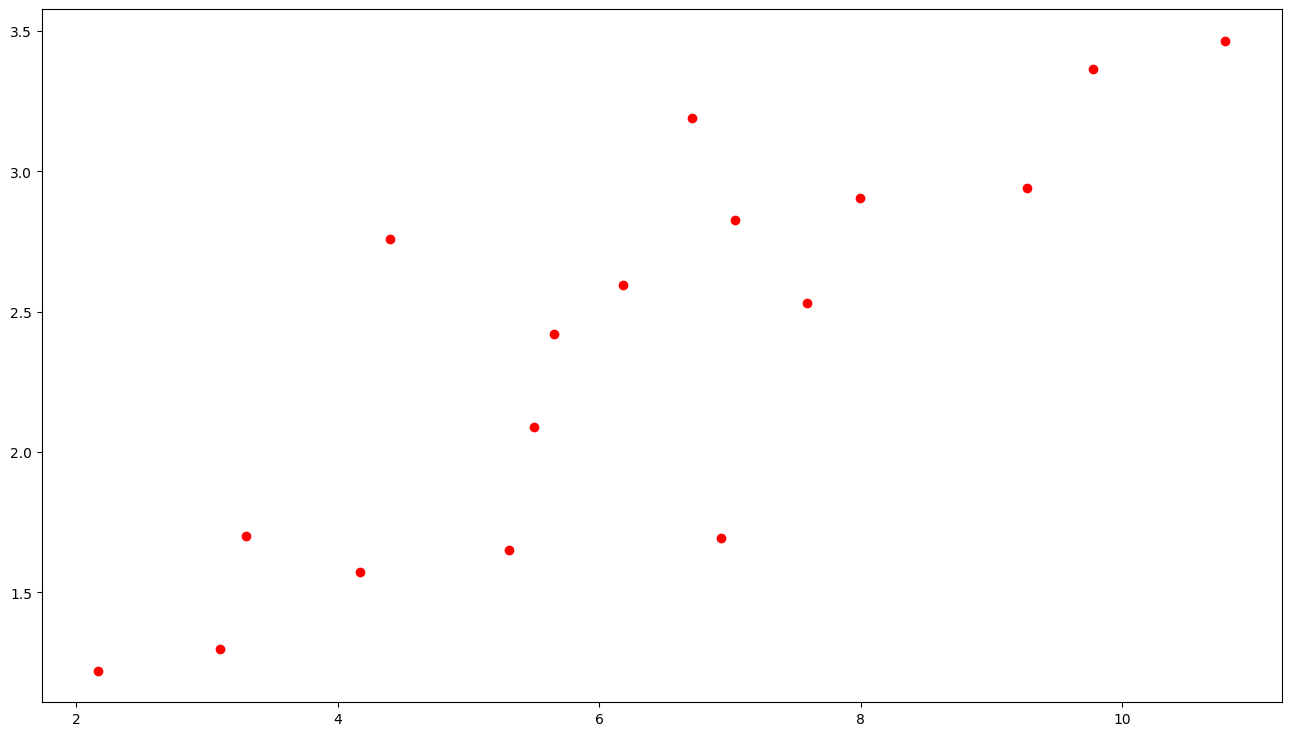

In [19]:
plt.figure(figsize = (16,9))
plt.scatter(X, y, color = 'red', marker = 'o')
plt.show()

In [62]:
def model(x):
    return x * w + b

In [28]:
# khởi tạo trọng số và bias ngẫu nhiên
w = torch.randn(1, requires_grad = True)
b = torch.randn(1, requires_grad = True)

In [58]:
# mse
def mse(t1 ,t2):
    diff = t1 - t2
    return torch.sum(diff * diff) / diff.numel()

In [63]:
preds = model(inputs)
preds

tensor([-3.9599, -4.8263, -5.6928, -6.6458, -6.8191, -4.6436, -9.0632, -6.2299,
        -7.3390, -3.0675, -6.9073, -9.8603, -5.5455, -7.6596, -5.8141, -8.6623,
        -3.8024], dtype=torch.float64, grad_fn=<AddBackward0>)

In [72]:
# loss khi chưa train
loss = mse(preds, targets)
loss

tensor(80.6072, dtype=torch.float64, grad_fn=<DivBackward0>)

In [73]:
loss.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [76]:
w.grad

tensor([-118.9468])

In [81]:
with torch.no_grad():
    w -= w.grad * learning_rate
    b -= b.grad * learning_rate
    w.grad.zero_()
    b.grad.zero_()

In [84]:
y_pred_after_train = model(inputs)
y_pred_after_train

tensor([ 0.3107,  0.7527,  1.1946,  1.6808,  1.7692,  0.6594,  2.9140,  1.4687,
         2.0344, -0.1446,  1.8142,  3.3206,  1.1195,  2.1979,  1.2565,  2.7094,
         0.2303], dtype=torch.float64, grad_fn=<AddBackward0>)

In [86]:
loss = mse(targets, y_pred_after_train)
loss

tensor(1.0495, dtype=torch.float64, grad_fn=<DivBackward0>)

In [87]:
print(w, b)

tensor([0.4018], requires_grad=True) tensor([-1.0153], requires_grad=True)


In [90]:
# training step chính là số epoch
# sau mỗi lần sử dụng zero_() để xóa đi grad thì các grad của w và b bị xóa hoàn toàn chỉ có giá trị của chúng được giữ nguyên được cập nhật từ epoch này qua epoch khác
losses = []
for i in range(training_steps):
    print(w, b)
    preds = model(inputs)
    loss = mse(preds, targets)
    losses.append(loss)
    loss.backward()
    with torch.no_grad():
        w -= w.grad*learning_rate
        b -= b.grad*learning_rate
        w.grad.zero_()
        b.grad.zero_()

tensor([0.2740], requires_grad=True) tensor([0.6405], requires_grad=True)
tensor([0.2739], requires_grad=True) tensor([0.6409], requires_grad=True)
tensor([0.2739], requires_grad=True) tensor([0.6412], requires_grad=True)
tensor([0.2738], requires_grad=True) tensor([0.6416], requires_grad=True)
tensor([0.2738], requires_grad=True) tensor([0.6420], requires_grad=True)
tensor([0.2737], requires_grad=True) tensor([0.6424], requires_grad=True)
tensor([0.2736], requires_grad=True) tensor([0.6428], requires_grad=True)
tensor([0.2736], requires_grad=True) tensor([0.6432], requires_grad=True)
tensor([0.2735], requires_grad=True) tensor([0.6435], requires_grad=True)
tensor([0.2735], requires_grad=True) tensor([0.6439], requires_grad=True)
tensor([0.2734], requires_grad=True) tensor([0.6443], requires_grad=True)
tensor([0.2734], requires_grad=True) tensor([0.6447], requires_grad=True)
tensor([0.2733], requires_grad=True) tensor([0.6450], requires_grad=True)
tensor([0.2733], requires_grad=True) t

In [97]:
losses

[tensor(0.1570, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1569, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1569, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1569, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1569, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1569, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1569, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1569, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1568, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1568, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1568, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1568, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1568, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1568, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1568, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(0.1567, dtype=torch.float64, grad_fn=<DivBackward0>),
 tensor(

giá trị lúc này của losses đang là 1 list của các tensor đang nằm trong đồ thị tính đạo hàm (đang được theo dõi), chú ý là không thể chèn trực tiếp các tensor làm đầu vào của plt được, và không thể chuyển các tensor đang được theo dõi đạo hàm thành các numpy array ngay được

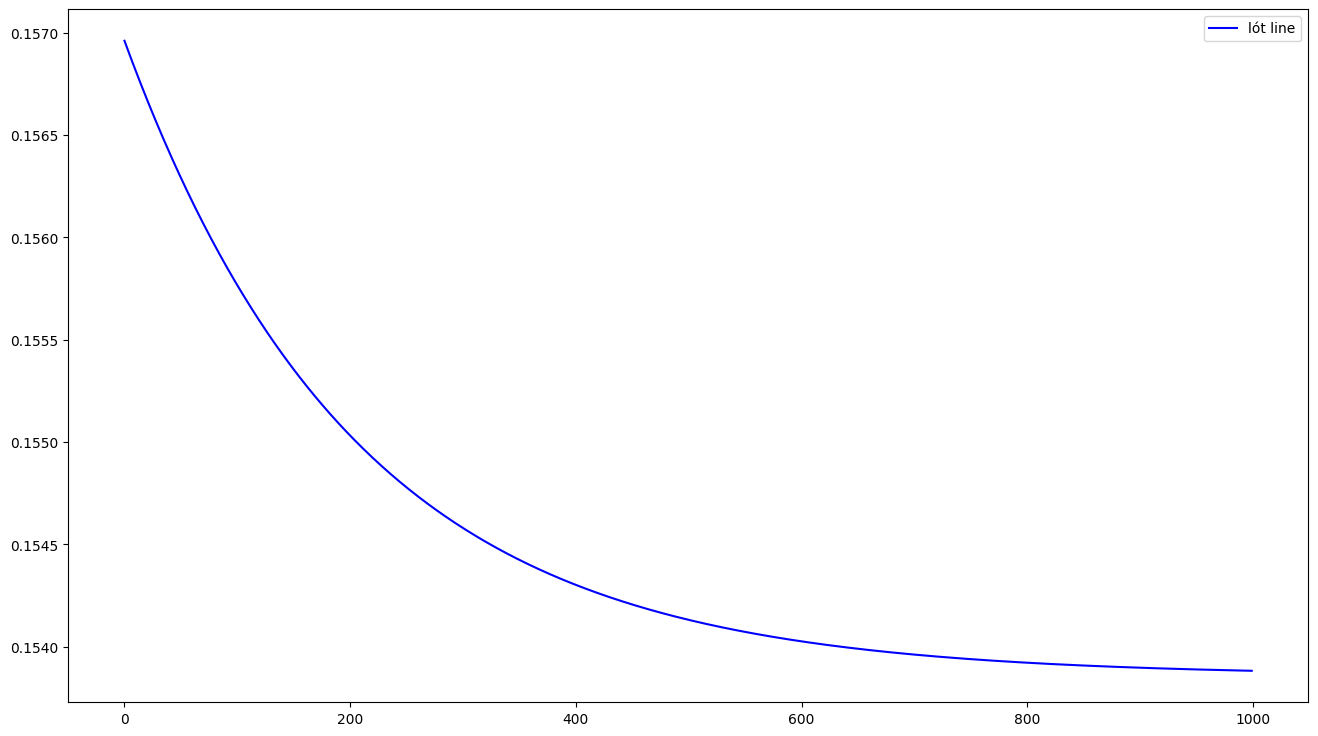

In [119]:
losses_in_list = [i.detach().item() for i in losses]
plt.figure(figsize = (16,9))
plt.plot(range(len(losses_in_list)), losses_in_list, color = 'b', label = 'lót line')
plt.legend(loc = 'best')
plt.show()

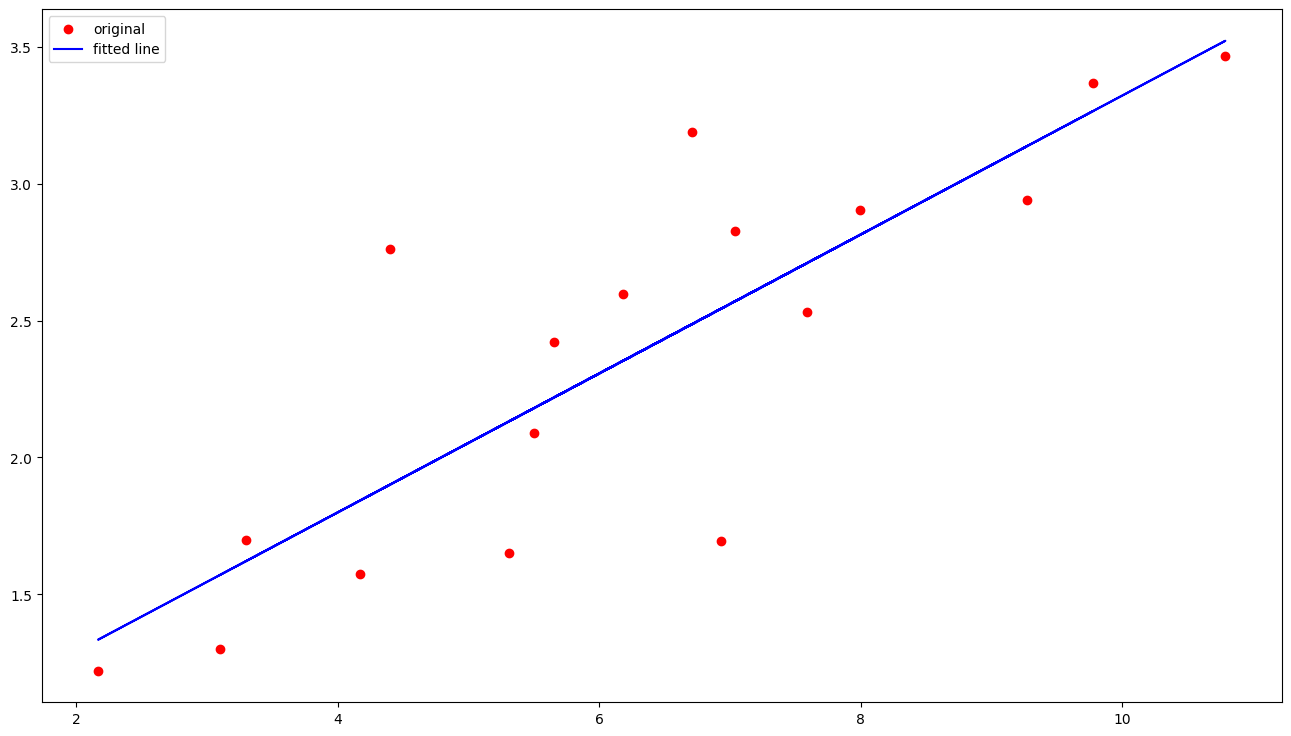

In [123]:
plt.figure(figsize = (16,9))
plt.scatter(X, y, color = 'red', marker = 'o', label = 'original')
plt.plot(X, (w.detach().numpy()*X + b.detach().numpy()), color = 'blue', label = 'fitted line')
plt.legend(loc = 'best')
plt.show()